# How similar are two molecules?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yboulaamane/cadd-labs/blob/main/Tanimoto_similarity.ipynb)

"Similar molecules tend to have similar properties" is one of the oldest rules of thumb in
drug discovery. But what does *similar* actually mean for a molecule, and how do you put a
number on it? This notebook answers that with **molecular fingerprints** and the **Tanimoto
coefficient**, the workhorse pair behind similarity search, clustering and virtual screening.

**What you'll do**

- Turn a molecule into a fingerprint and see what its "bits" actually represent.
- Score how alike two molecules are, from 0 (nothing in common) to 1 (identical fingerprints).
- Compare a whole set at once and read the result as a heatmap.

No prior cheminformatics needed. Runs on a free CPU runtime in under a minute.

## Setup

The one package to add is **RDKit**, the open-source cheminformatics toolkit. NumPy, Matplotlib
and seaborn are already on Colab.

In [ ]:
%pip install -q rdkit seaborn

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from rdkit import Chem, DataStructs
from rdkit.Chem import Draw, rdFingerprintGenerator

# One plotting style for the whole notebook: large fonts, soft grid, clean spines.
sns.set_theme(style="whitegrid", context="talk", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titleweight": "bold",
    "axes.titlesize": 16,
    "axes.titlepad": 14,
    "savefig.bbox": "tight",
})

## 1. What is a molecular fingerprint?

A fingerprint turns a structure into a long string of 0s and 1s. A **Morgan fingerprint** looks
at the circular neighbourhood around each atom, out to a chosen radius, and switches on a bit for
every fragment it finds. Two molecules that share many fragments share many bits.

Here are three of the fragments (bits) found in coumarin. Each panel highlights the atom (blue)
and the shell of neighbours that set that bit.

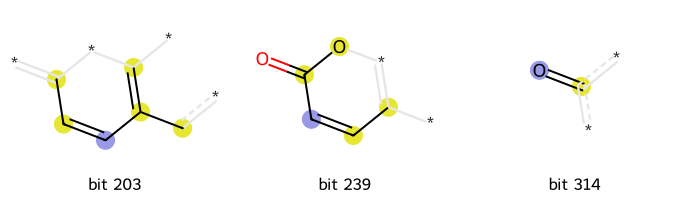

In [3]:
morgan = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

coumarin = Chem.MolFromSmiles("O=c1ccc2ccccc2o1")
info = rdFingerprintGenerator.AdditionalOutput()
info.AllocateBitInfoMap()
morgan.GetFingerprint(coumarin, additionalOutput=info)

bits = list(info.GetBitInfoMap())[:3]
Draw.DrawMorganBits([(coumarin, b, info.GetBitInfoMap()) for b in bits],
                    legends=[f"bit {b}" for b in bits],
                    molsPerRow=3, subImgSize=(230, 200))

The full fingerprint used below has 2048 bits at radius 2 (roughly the ECFP4 setting that most
similarity work uses). A molecule usually lights up a few dozen of them.

In [4]:
def fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"RDKit could not read this SMILES: {smiles}")
    return morgan.GetFingerprint(mol)


print("Coumarin sets", sum(fingerprint("O=c1ccc2ccccc2o1")), "of 2048 bits")

Coumarin sets 20 of 2048 bits


## 2. Comparing two molecules

The **Tanimoto coefficient** is the share of bits the two molecules agree on: the bits set in
*both*, divided by the bits set in *either*. Let's compare coumarin with warfarin, a
coumarin-based anticoagulant.

Tanimoto similarity: 0.239


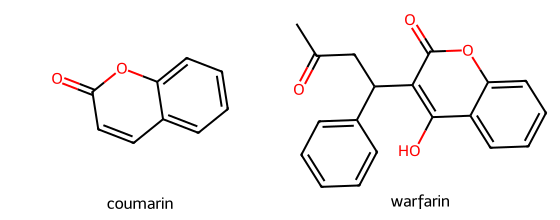

In [5]:
def tanimoto(smiles1, smiles2):
    return round(DataStructs.TanimotoSimilarity(fingerprint(smiles1), fingerprint(smiles2)), 3)


pair = {"coumarin": "O=c1ccc2ccccc2o1",
        "warfarin": "CC(=O)CC(c1ccccc1)c1c(O)c2ccccc2oc1=O"}
score = tanimoto(*pair.values())

img = Draw.MolsToGridImage([Chem.MolFromSmiles(s) for s in pair.values()],
                           legends=list(pair), molsPerRow=2, subImgSize=(280, 220))
print(f"Tanimoto similarity: {score}")
img

They share the coumarin core, so they have a fair amount in common, but warfarin's extra rings
and side chain pull the score well below 1. A value around 0.3 and up is often treated as
"worth a look" for a similarity search, though the right cut-off depends on the project.

## 3. Comparing a whole set

Searching a library means comparing many molecules at once. `BulkTanimotoSimilarity` scores one
fingerprint against a list in a single fast call. Below is a small set of natural products and
drugs; the heatmap shows every pairwise similarity.

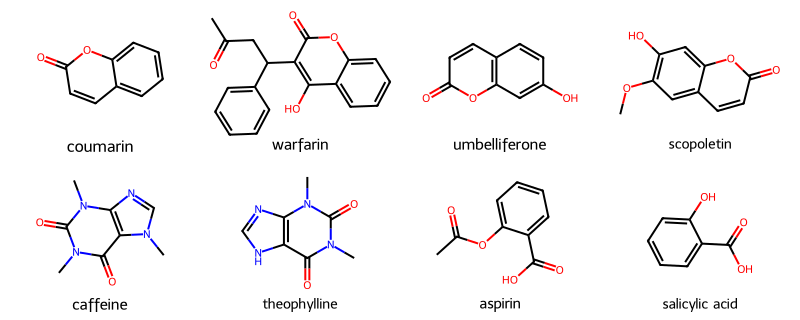

In [6]:
molecules = {
    "coumarin": "O=c1ccc2ccccc2o1",
    "warfarin": "CC(=O)CC(c1ccccc1)c1c(O)c2ccccc2oc1=O",
    "umbelliferone": "O=c1ccc2ccc(O)cc2o1",
    "scopoletin": "COc1cc2ccc(=O)oc2cc1O",
    "caffeine": "Cn1cnc2c1c(=O)n(C)c(=O)n2C",
    "theophylline": "Cn1c(=O)c2[nH]cnc2n(C)c1=O",
    "aspirin": "CC(=O)Oc1ccccc1C(=O)O",
    "salicylic acid": "O=C(O)c1ccccc1O",
}
Draw.MolsToGridImage([Chem.MolFromSmiles(s) for s in molecules.values()],
                     legends=list(molecules), molsPerRow=4, subImgSize=(200, 160))

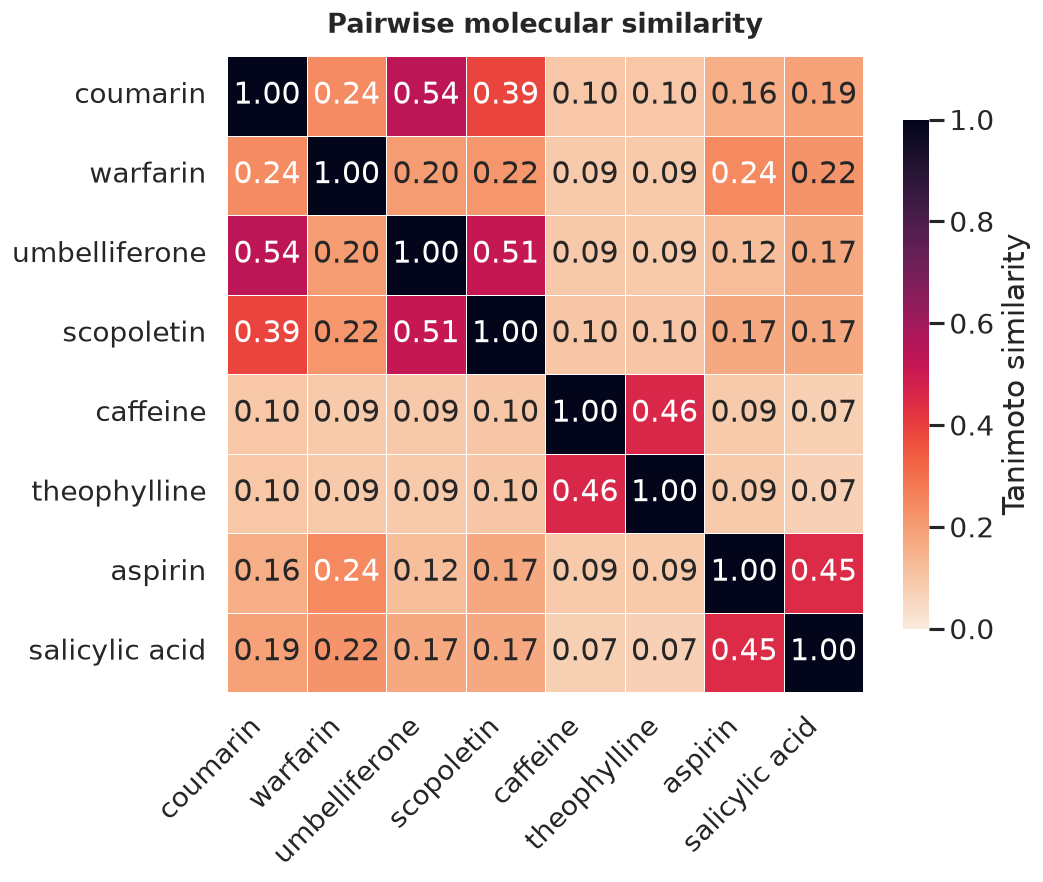

In [7]:
names = list(molecules)
fps = [fingerprint(s) for s in molecules.values()]
matrix = np.array([DataStructs.BulkTanimotoSimilarity(fp, fps) for fp in fps])

fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(matrix, xticklabels=names, yticklabels=names, annot=True, fmt=".2f",
            cmap="rocket_r", vmin=0, vmax=1, square=True, linewidths=.5,
            cbar_kws={"label": "Tanimoto similarity", "shrink": .8}, ax=ax)
ax.set_title("Pairwise molecular similarity")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

The blocks of warm colour are chemical families finding each other: the three coumarins cluster,
caffeine pairs with theophylline, and aspirin pairs with salicylic acid. That clustering, done at
scale, is exactly how a fingerprint search pulls look-alikes of a known active out of a library.

Most similar pair: coumarin and umbelliferone (Tanimoto 0.54)


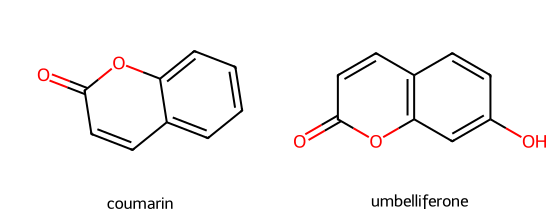

In [8]:
pairs = [(matrix[i, j], names[i], names[j])
         for i in range(len(names)) for j in range(i + 1, len(names))]
top = sorted(pairs, reverse=True)[0]
print(f"Most similar pair: {top[1]} and {top[2]} (Tanimoto {top[0]:.2f})")

Draw.MolsToGridImage([Chem.MolFromSmiles(molecules[top[1]]), Chem.MolFromSmiles(molecules[top[2]])],
                     legends=[top[1], top[2]], molsPerRow=2, subImgSize=(280, 220))

## Takeaways

- A **fingerprint** encodes which fragments a molecule contains; the **Tanimoto coefficient**
  measures how many fragments two molecules share.
- Similarity depends on the settings. A larger radius looks at bigger fragments and usually lowers
  the scores, so only compare numbers computed the same way.
- Fingerprint similarity sees *substructure* overlap, not 3D shape or actual activity. It is a fast
  first filter, not the final word.

**Try it yourself:** swap in your own SMILES, change the Morgan radius to 3, or raise the
"worth a look" cut-off and see which pairs survive.